In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
import tifffile as tf
from pathlib import Path
from cilia_utils.utils import *
from cilia_utils.plotting_utils import *

In [4]:
path = Path("/group/jug/aman/Cilia_Predictions_03Dec25/")
path.mkdir(parents = True, exist_ok = True)
imgs = tf.imread("./data/DP/max_projection.tif")
predictions = tf.imread(path/"predictions_cilia_unconnected.tif")

In [5]:
predictions, _ = binarize_and_correct_tiff(predictions)

In [6]:
print("Thresholding Cilia Channel based on the Red Channel")
predictions_cleaned = keep_connected_blobs(predictions, target_channel= 3, reference_channel=2)
print("\nThresholding the Red Channel using cleaned Cilia Channel")
predictions_cleaned = keep_connected_blobs(predictions_cleaned, target_channel= 2, reference_channel=3)
print("\nComputing the intersection of Green Protein Channel and Cleaned Cilia Channel")
predictions_cleaned[...,1] = intersect_channels(predictions_cleaned, channel1= 1, channel2=3)

Thresholding Cilia Channel based on the Red Channel


100%|██████████| 180/180 [00:00<00:00, 6486.54it/s]



Thresholding the Red Channel using cleaned Cilia Channel


100%|██████████| 180/180 [00:00<00:00, 23174.37it/s]


Computing the intersection of Green Protein Channel and Cleaned Cilia Channel


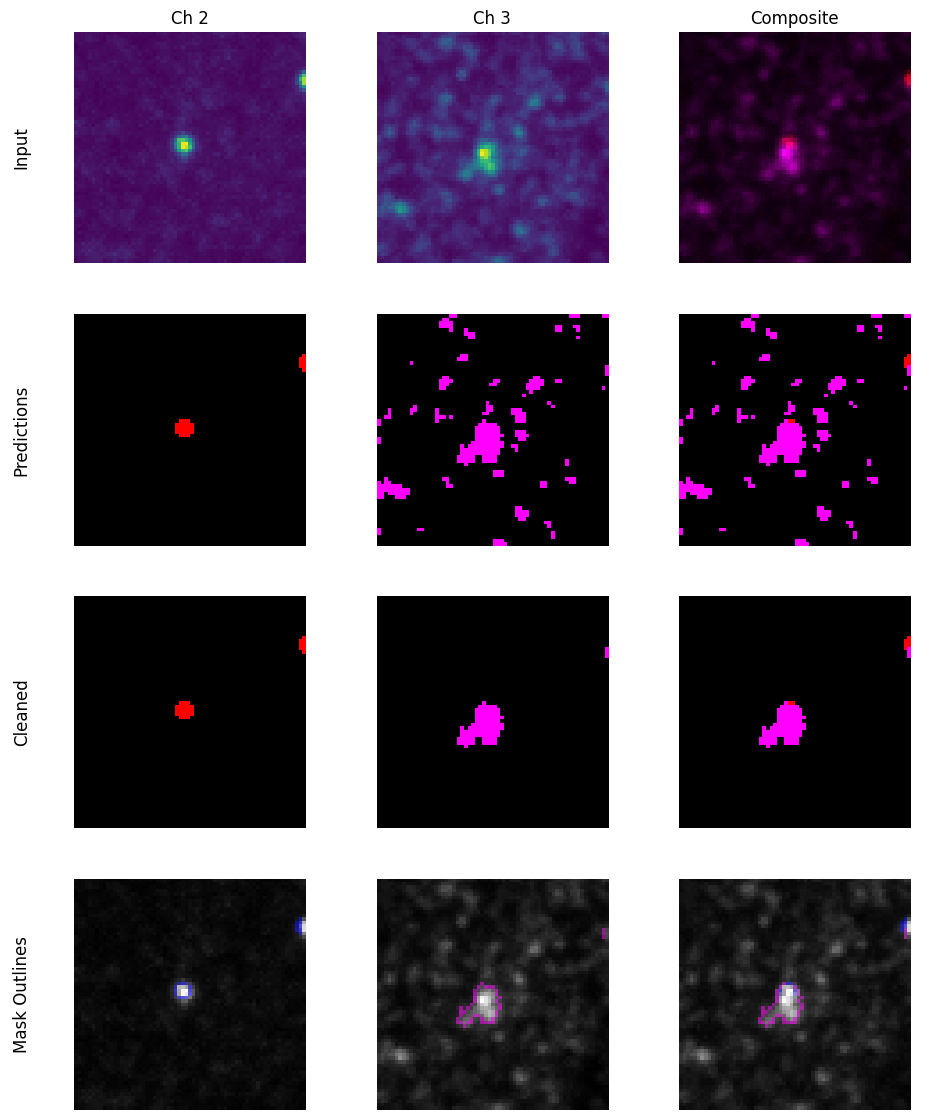

In [10]:
idx = 3
plot_input_and_predictions_with_outline(idx, imgs, predictions, predictions_cleaned, [2,3], scale = 'minmax', linewidth=1, overlay_alpha= 0.5)